In [1]:
import os
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from imblearn.over_sampling import SMOTE

In [2]:

data_path = "./Dataset_BUSI_with_GT"
image_size = (128, 128)
classes = ["benign", "malignant", "normal"]

X, y = [], []
for idx, category in enumerate(classes):
    category_path = os.path.join(data_path, category)
    for file in os.listdir(category_path):
        file_path = os.path.join(category_path, file)
        try:
            img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
            img_resized = cv2.resize(img, image_size)
            X.append(img_resized)
            y.append(idx)
        except Exception as e:
            print(f"Error loading image {file_path}: {e}")


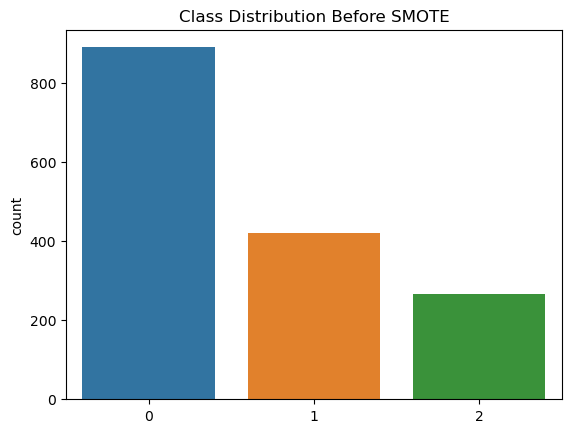

In [3]:


X = np.array(X).reshape(-1, image_size[0], image_size[1], 1) / 255.0
y = np.array(y)


sns.countplot(x=y)
plt.title("Class Distribution Before SMOTE")
plt.show()

smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X.reshape(X.shape[0], -1), y)
X_resampled = X_resampled.reshape(-1, image_size[0], image_size[1], 1)
y_resampled = to_categorical(y_resampled, num_classes=len(classes))


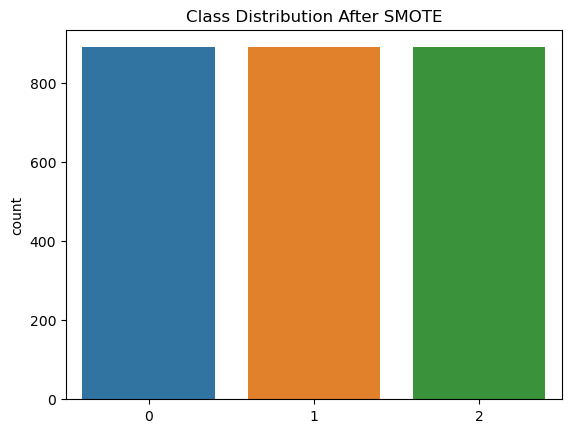

In [4]:
sns.countplot(x=np.argmax(y_resampled, axis=1))
plt.title("Class Distribution After SMOTE")
plt.show()

In [5]:

X_train, X_temp, y_train, y_temp = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
datagen.fit(X_train)


In [6]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(image_size[0], image_size[1], 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(classes), activation='softmax')
])


model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)


history = model.fit(datagen.flow(X_train, y_train, batch_size=32),
                    validation_data=(X_val, y_val),
                    epochs=10,
                    callbacks=[early_stopping, reduce_lr])

C:\Users\91636\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\91636\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 39s 621ms/step - accuracy: 0.5005 - loss: 7.6216 - val_accuracy: 0.2993 - val_loss: 20.9914 - learning_rate: 0.0010
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 34s 576ms/step - accuracy: 0.5582 - loss: 2.3693 - val_accuracy: 0.2993 - val_loss: 21.3892 - learning_rate: 0.0010
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 34s 574ms/step - accuracy: 0.5510 - loss: 1.7328 - val_accuracy: 0.3092 - val_loss: 11.6499 - learning_rate: 0.0010
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 34s 576ms/step - accuracy: 0.5617 - loss: 1.4096 - val_accuracy: 0.3416 - val_loss: 13.1525 - learning_rate: 0.0010
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 35s 586ms/step - accuracy: 0.5611 - loss: 0.8841 - val_accuracy: 0.3292 - val_loss: 9.8604 - learning_rate: 0.0010
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 34s 576ms/step - accuracy: 0.5848 - loss: 0.8852 - val_accuracy: 0.3516 - val_loss: 9.2721 - learning_rate: 0.0010
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 34s 576ms/step - accuracy: 0.6044 - loss

In [8]:

test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)
cm = confusion_matrix(y_true, y_pred)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.6457 - loss: 0.6629
Test Accuracy: 65.59%
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.6457 - loss: 0.6629
Test Accuracy: 65.59%
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step


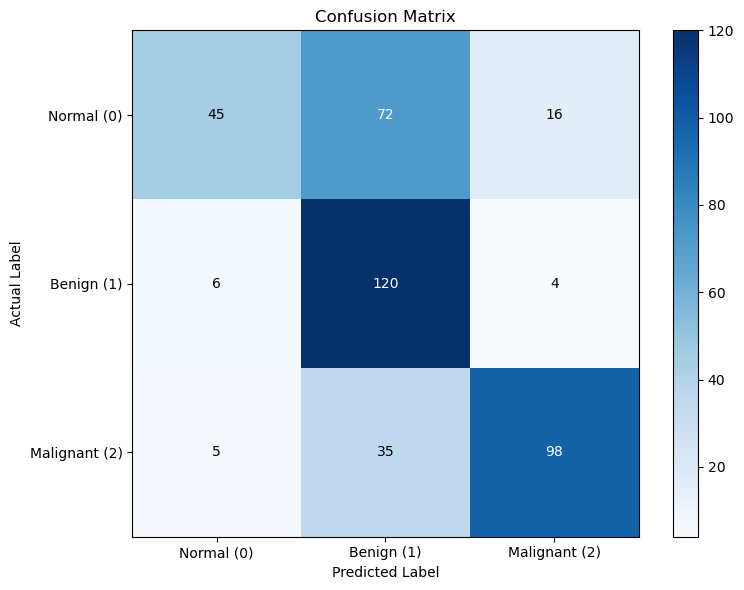

Classification Report:
                precision    recall  f1-score   support

   Normal (0)       0.80      0.34      0.48       133
   Benign (1)       0.53      0.92      0.67       130
Malignant (2)       0.83      0.71      0.77       138

     accuracy                           0.66       401
    macro avg       0.72      0.66      0.64       401
 weighted avg       0.72      0.66      0.64       401



In [9]:



test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)
conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))  
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()


tick_marks = np.arange(len(np.unique(y_true))) 
plt.xticks(tick_marks, labels=["Normal (0)", "Benign (1)", "Malignant (2)"], rotation=0)
plt.yticks(tick_marks, labels=["Normal (0)", "Benign (1)", "Malignant (2)"])


thresh = conf_matrix.max() / 2. 
for i, j in np.ndindex(conf_matrix.shape):
    plt.text(j, i, format(conf_matrix[i, j], 'd'),
             ha="center", va="center",
             color="white" if conf_matrix[i, j] > thresh else "black")

plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


classes = ["Normal (0)", "Benign (1)", "Malignant (2)"] 
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=classes))

In [10]:
model.save("cnn_model_77acc.h5")  
